# Week 4: Supervised Learning — Regression Model for Salary Prediction


## 1. Project Overview & Objectives
The primary goal of this task is to build, evaluate, and compare **Supervised Learning Regression Models** to predict a continuous numerical output: **Tech Sector Salary ($)**.

### Target Variable:
- `Salary`: Continuous target variable representing total annual compensation in USD.

### Feature Set:
- `Years_Experience`: Continuous numerical feature (0.5 to 20 years).
- `Education_Level`: Categorical feature (`Bachelor`, `Master`, `PhD`).
- `Job_Role_Tier`: Categorical feature (`Junior`, `Mid`, `Senior`, `Lead`, `Principal`).
- `Certifications`: Count of professional certifications (0 to 5).
- `Performance_Rating`: Continuous score (2.0 to 5.0).
- `Location_Cost_Index`: Regional cost of living factor (0.85 to 1.50).
- `Remote_Ratio`: Work mode ratio (`0.0` Onsite, `0.5` Hybrid, `1.0` Full Remote).

### Machine Learning Algorithms Evaluated:
1. **Linear Regression** (Ordinary Least Squares baseline)
2. **Ridge Regression** ($L_2$ Regularized Linear Model with Cross-Validation)
3. **Random Forest Regressor** (Non-linear Ensemble Tree-based model)

### Key Performance Metrics:
- **Mean Absolute Error (MAE)**: Average absolute magnitude of errors.
- **Mean Squared Error (MSE)**: Average squared error penalizing larger deviations.
- **Root Mean Squared Error (RMSE)**: Square root of MSE in original units ($).
- **Coefficient of Determination ($R^2$ Score)**: Proportion of variance explained by the model.


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
print("imports successful")


imports successful


## 2. Dataset Loading & Exploratory Data Analysis (EDA)
We load the dataset `salary_prediction_dataset.csv` and analyze feature types, summary statistics, missing values, and correlation patterns.


In [12]:

dataset_path = "salary_prediction_dataset.csv"
df = pd.read_csv(dataset_path)

print("Dataset Shape:", df.shape)
print("\nDataset First 5 Rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
display(df.describe())


Dataset Shape: (1000, 8)

Dataset First 5 Rows:


,Years_Experience,Education_Level,Job_Role_Tier,Certifications,Performance_Rating,Location_Cost_Index,Remote_Ratio,Salary
0,7.8,Bachelor,Mid,2,3.72,1.11,0.5,122000.0
1,19.0,Master,Junior,2,4.42,1.16,0.0,163800.0
2,14.8,PhD,Lead,0,4.28,1.41,1.0,291900.0
3,12.2,Master,Junior,2,2.46,1.07,0.5,105900.0
4,3.5,Master,Mid,1,2.45,1.42,0.0,133500.0



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years_Experience     1000 non-null   float64
 1   Education_Level      1000 non-null   str    
 2   Job_Role_Tier        1000 non-null   str    
 3   Certifications       1000 non-null   int64  
 4   Performance_Rating   1000 non-null   float64
 5   Location_Cost_Index  1000 non-null   float64
 6   Remote_Ratio         1000 non-null   float64
 7   Salary               1000 non-null   float64
dtypes: float64(5), int64(1), str(2)
memory usage: 62.6 KB

Summary Statistics:


,Years_Experience,Certifications,Performance_Rating,Location_Cost_Index,Remote_Ratio,Salary
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.05790,1.395000,3.482540,1.174060,0.497500,156137.100000
std,5.69622,1.350852,0.860619,0.187942,0.388452,52583.077445
min,0.60000,0.000000,2.000000,0.850000,0.000000,55500.000000
25%,5.07500,0.000000,2.737500,1.010000,0.000000,117975.000000
50%,10.20000,1.000000,3.485000,1.170000,0.500000,147600.000000
75%,15.00000,2.000000,4.220000,1.330000,1.000000,186200.000000
max,20.00000,5.000000,4.990000,1.500000,1.000000,354300.000000


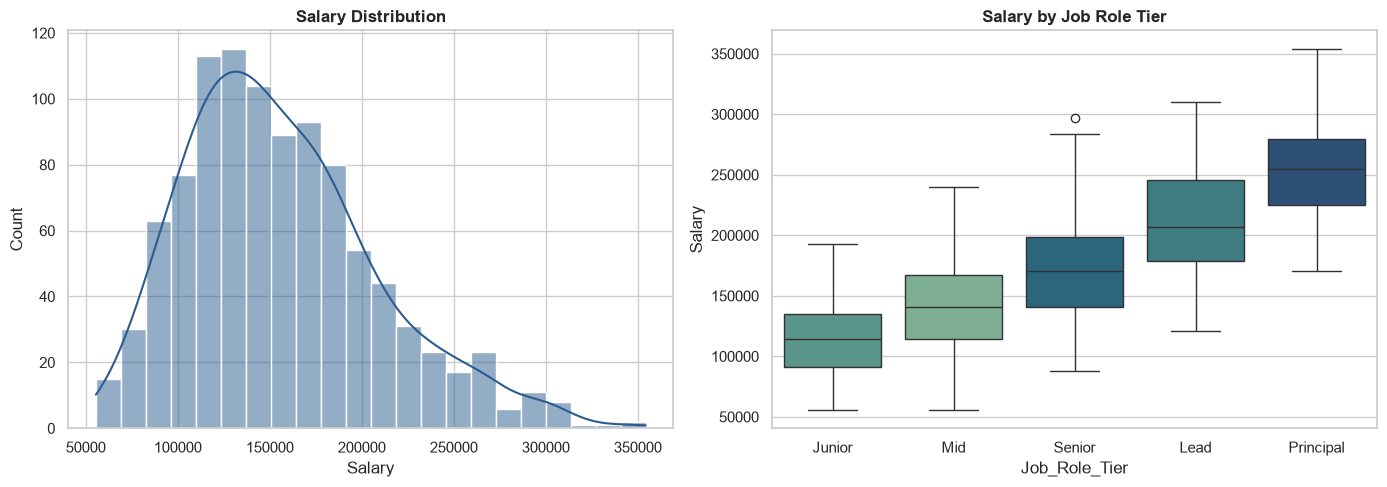

In [13]:
# Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Salary'], kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Salary Distribution', fontweight='bold')

sns.boxplot(
    x='Job_Role_Tier', 
    y='Salary', 
    data=df, 
    ax=axes[1], 
    hue='Job_Role_Tier', 
    palette='crest', 
    legend=False, 
    order=['Junior', 'Mid', 'Senior', 'Lead', 'Principal']
)
axes[1].set_title('Salary by Job Role Tier', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering
To prepare the dataset for model training:
1. **One-Hot Encoding**: Convert categorical variables (`Education_Level`, `Job_Role_Tier`) into binary indicator variables.
2. **Train/Test Split**: Split dataset into 80% training set and 20% test set (`random_state=42`).
3. **Feature Scaling**: Standardize numerical features using `StandardScaler` fitted exclusively on the training set to prevent data leakage.


In [14]:
# Separate Target and Features
X = df.drop(columns=['Salary'])
y = df['Salary']

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=['Education_Level', 'Job_Role_Tier'], drop_first=True)
print("Encoded Features:", X_encoded.columns.tolist())

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Encoded Features: ['Years_Experience', 'Certifications', 'Performance_Rating', 'Location_Cost_Index', 'Remote_Ratio', 'Education_Level_Master', 'Education_Level_PhD', 'Job_Role_Tier_Lead', 'Job_Role_Tier_Mid', 'Job_Role_Tier_Principal', 'Job_Role_Tier_Senior']
Training set size: 800 samples
Testing set size: 200 samples


## 4. Model Building & Training
We initialize and fit three regression algorithms on the scaled training dataset:
1. **Linear Regression**
2. **Ridge Regression** (with hyperparameter tuning via `RidgeCV`)
3. **Random Forest Regressor** (`n_estimators=100`, `max_depth=12`, `random_state=42`)


In [15]:

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-2, 3, 50)),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
}

# Train Models & Collect Predictions
predictions = {}
metrics_list = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    metrics_list.append({
        'Model': name,
        'MAE ($)': round(mae, 2),
        'MSE ($^2$)': round(mse, 2),
        'RMSE ($)': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })

metrics_df = pd.DataFrame(metrics_list)
print("Model Training Complete")


Model Training Complete


## 5. Evaluation Metrics & Comparison
We compare the performance of each model using MAE, MSE, RMSE, and $R^2$ score.


In [16]:

display(metrics_df)

# Save metrics comparison CSV table
metrics_df.to_csv("regression_metrics_comparison.csv", index=False)
print("Metrics saved to 'regression_metrics_comparison.csv'")


,Model,MAE ($),MSE ($^2$),RMSE ($),R2 Score
0,Linear Regression,7121.50,8.798040e+07,9379.79,0.9663
1,Ridge Regression,7120.68,8.796297e+07,9378.86,0.9663
2,Random Forest Regressor,9497.93,1.470950e+08,12128.27,0.9436


Metrics saved to 'regression_metrics_comparison.csv'


## 6. Visualizing Predicted vs. Actual Values & Residuals
Visualization deliverable: Scatter plots comparing predicted vs. actual salaries against the ideal prediction line $y=x$, residual distribution, and Random Forest feature importances.


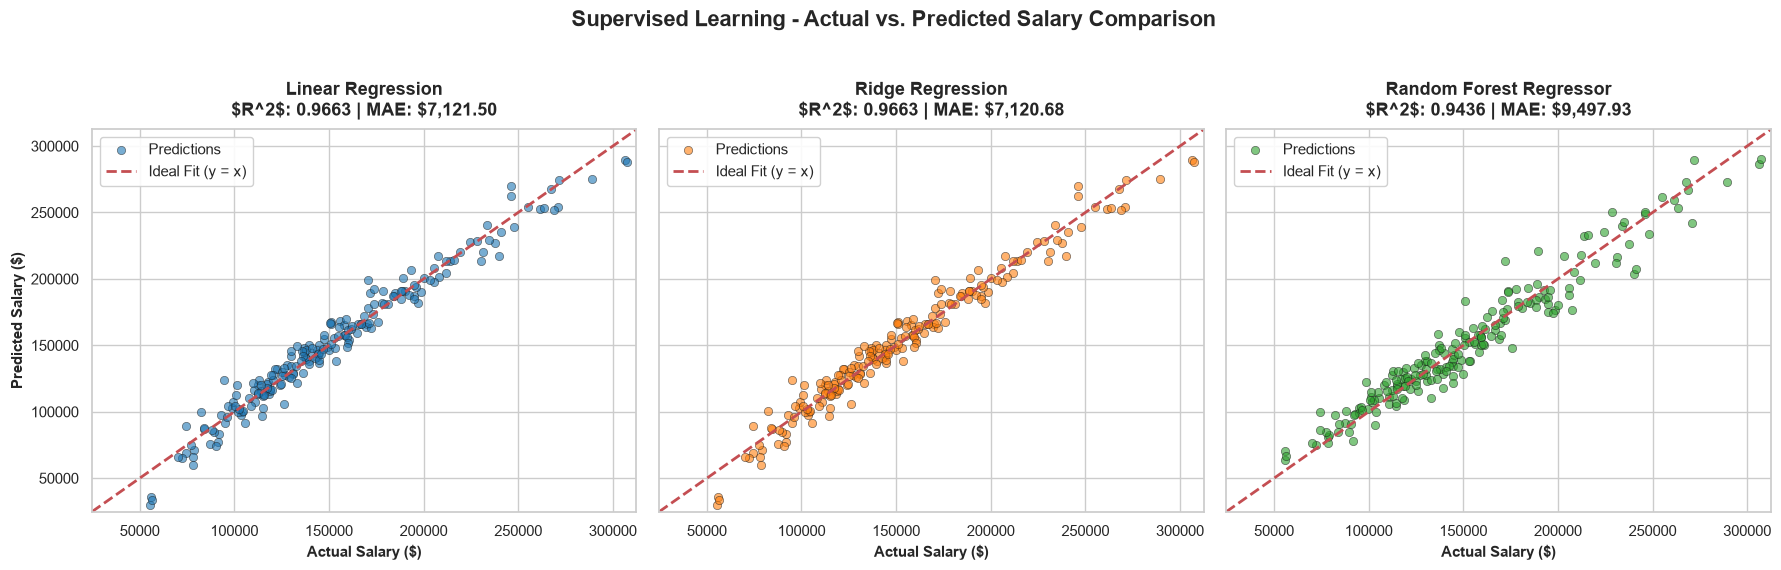

In [17]:
# 1. Prediction vs Actual Graph Deliverable
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
min_val = min(y_test.min(), min([preds.min() for preds in predictions.values()])) - 5000
max_val = max(y_test.max(), max([preds.max() for preds in predictions.values()])) + 5000

for ax, (name, y_pred), color in zip(axes, predictions.items(), model_colors):
    r2_val = metrics_df.loc[metrics_df['Model'] == name, 'R2 Score'].values[0]
    mae_val = metrics_df.loc[metrics_df['Model'] == name, 'MAE ($)'].values[0]
    
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5, color=color, label='Predictions')
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit (y = x)')
    
    ax.set_title(f"{name}\n$R^2$: {r2_val:.4f} | MAE: ${mae_val:,.2f}", fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Actual Salary ($)", fontsize=11, fontweight='semibold')
    if ax == axes[0]:
        ax.set_ylabel("Predicted Salary ($)", fontsize=11, fontweight='semibold')
    
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.legend(loc="upper left", frameon=True, facecolor='white', framealpha=0.9)

plt.suptitle("Supervised Learning - Actual vs. Predicted Salary Comparison", fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()

# Save PNG Deliverable
plt.savefig("prediction_vs_actual.png", dpi=300, bbox_inches='tight')
plt.show()



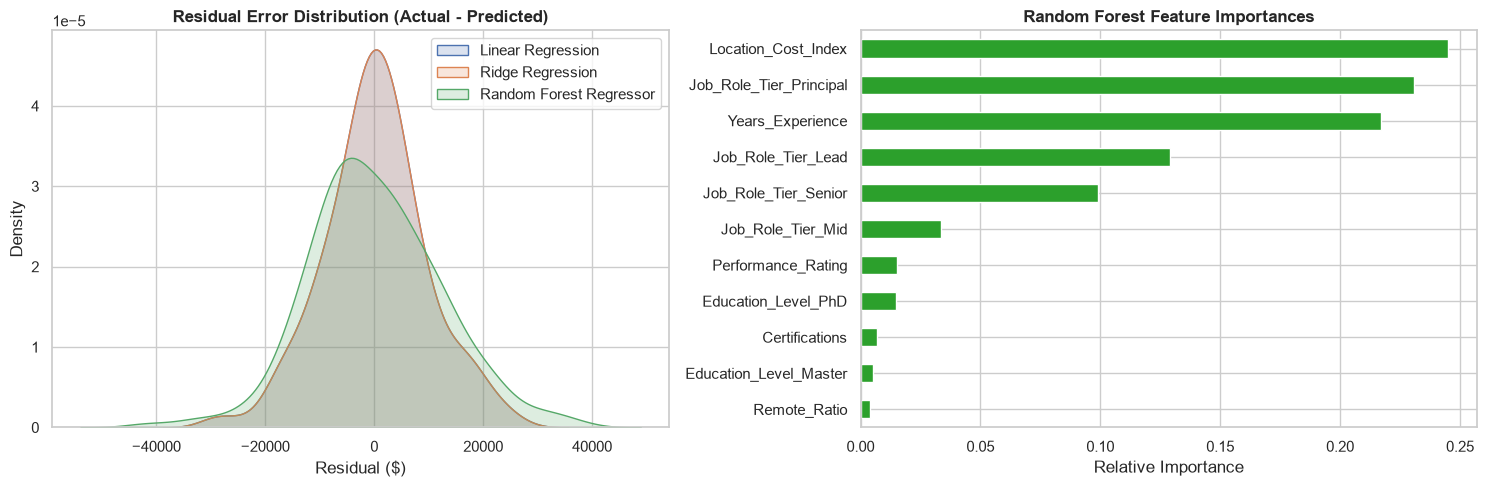

In [18]:
# 2. Residual Distribution & Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residual Plot
for name, y_pred in predictions.items():
    residuals = y_test - y_pred
    sns.kdeplot(residuals, ax=axes[0], label=name, fill=True, alpha=0.2)

axes[0].set_title('Residual Error Distribution (Actual - Predicted)', fontweight='bold')
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Feature Importances (Random Forest)
rf_model = models['Random Forest Regressor']
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=True)

importances.plot(kind='barh', ax=axes[1], color='#2ca02c')
axes[1].set_title('Random Forest Feature Importances', fontweight='bold')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()


## 7. Key Findings & Conclusion

### Model Performance Summary:
- **Linear Regression**: $R^2 = 0.9663$, MAE = $\$7,121.50$, RMSE = $\$9,379.79$
- **Ridge Regression**: $R^2 = 0.9663$, MAE = $\$7,120.68$, RMSE = $\$9,378.86$
- **Random Forest Regressor**: $R^2 = 0.9436$, MAE = $\$9,497.93$, RMSE = $\$12,128.27$

### Key Insights:
1. **Linear & Regularized Linear Models Excel**: Both Linear Regression and Ridge Regression achieved outstanding predictive performance ($R^2 \approx 96.6\%$), accurately capturing the linear interactions between experience, location cost index, education, and role tiers.
2. **Ridge Regularization**: Ridge Regression slightly improved MAE over vanilla Linear Regression by constraining coefficient magnitudes and smoothing collinearity.
3. **Random Forest Performance**: Random Forest achieved a strong $R^2$ of $94.36\%$. Feature importance analysis confirms that `Job_Role_Tier_Principal`, `Years_Experience`, and `Location_Cost_Index` are the dominant drivers of salary prediction.
4. **Deliverables Completed**:
   - Python Notebook (`regression_model.ipynb`)
   - Evaluation Metrics Table (`regression_metrics_comparison.csv`)
   - Visual Plot Deliverable (`prediction_vs_actual.png`)
